파일 불러오기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/K조선 해커톤')  # 폴더 안 파일 목록 확인

['K_ShipMake.ipynb',
 'eta_synthetic_logs.csv',
 'yard-logistics-prototype.html',
 'K-shipbuilding-hackathon-plan-draft.pptx']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/K조선 해커톤/eta_synthetic_logs.csv')
df.head()

,distance_m,weight_t,length_m,width_m,footprint_m2,turns,hour,congestion,true_min
0,946.830774,289.621536,22.17,6.01,133.2,1,13,3,7.207876
1,571.543853,97.749054,16.08,20.58,331.0,4,12,0,5.379669
2,1041.629670,354.428853,5.78,24.74,142.9,1,11,1,7.127047
3,861.052193,119.164432,39.67,10.93,433.5,3,10,4,6.912333
4,185.478630,64.746250,9.47,22.04,208.6,5,9,1,5.352353


한글 폰트 추가

In [ ]:
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

데이터 불러오기 + 확인

In [ ]:
df = pd.read_csv("eta_synthetic_logs.csv")
print(df.shape)   # (행 수, 열 수) 확인
df.head()

(6000, 9)


,distance_m,weight_t,length_m,width_m,footprint_m2,turns,hour,congestion,true_min
0,946.830774,289.621536,22.17,6.01,133.2,1,13,3,7.207876
1,571.543853,97.749054,16.08,20.58,331.0,4,12,0,5.379669
2,1041.629670,354.428853,5.78,24.74,142.9,1,11,1,7.127047
3,861.052193,119.164432,39.67,10.93,433.5,3,10,4,6.912333
4,185.478630,64.746250,9.47,22.04,208.6,5,9,1,5.352353


In [ ]:
df.describe()

,distance_m,weight_t,length_m,width_m,footprint_m2,turns,hour,congestion,true_min
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,634.115595,315.432310,21.621052,14.076380,303.937867,2.489833,12.026833,2.004167,6.253293
std,322.877966,164.098543,10.705498,6.356305,215.785280,1.698149,3.712287,1.416857,2.699228
min,80.352150,30.007506,3.000000,3.000000,10.000000,0.000000,6.000000,0.000000,1.000000
25%,352.932161,172.385873,12.247500,8.637500,129.800000,1.000000,9.000000,1.000000,4.277620
50%,631.385034,318.385165,21.770000,14.140000,246.950000,2.000000,12.000000,2.000000,6.090524
75%,916.808677,454.193706,30.872500,19.670000,437.050000,4.000000,15.000000,3.000000,8.097719
max,1199.737177,599.986902,40.000000,25.000000,972.800000,5.000000,18.000000,9.000000,15.300174


특징(X)과 정답(y) 정의

In [ ]:
features = ["distance_m", "weight_t", "footprint_m2", "turns", "hour", "congestion"]
X = df[features]
y = df["true_min"]

학습용/평가용 데이터 나누기

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(len(X_train), "건으로 학습 /", len(X_test), "건으로 평가")

4500 건으로 학습 / 1500 건으로 평가


베이스라인 (지금 프로토타입 방식: 거리만 보는 규칙)

In [ ]:
c = (df["distance_m"] / df["true_min"]).median()
baseline_pred = X_test["distance_m"] / c

선형회귀 학습

In [ ]:
lin = LinearRegression()
lin.fit(X_train, y_train)
lin_pred = lin.predict(X_test)

랜덤포레스트 학습

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

세 모델 성능 비교

In [ ]:
for name, pred in [
    ("베이스라인", baseline_pred),
    ("선형회귀", lin_pred),
    ("랜덤포레스트", rf_pred),
]:
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name:12s} MAE={mae:.2f}분   R²={r2:.3f}")

베이스라인        MAE=1.63분   R²=0.441
선형회귀         MAE=0.55분   R²=0.930
랜덤포레스트       MAE=0.51분   R²=0.933


모델별 오차 막대그래프

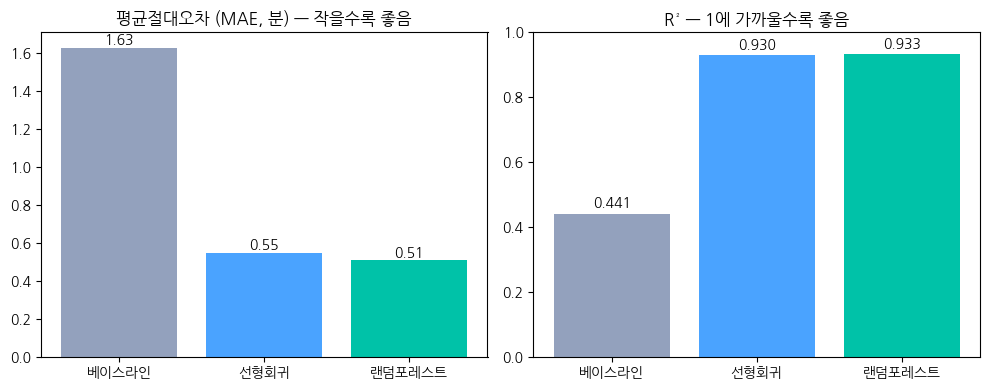

In [ ]:
results = pd.DataFrame({
    "모델": ["베이스라인", "선형회귀", "랜덤포레스트"],
    "MAE": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, lin_pred),
        mean_absolute_error(y_test, rf_pred),
    ],
    "R2": [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, lin_pred),
        r2_score(y_test, rf_pred),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(results["모델"], results["MAE"], color=["#93a1bd", "#4aa3ff", "#00c2a8"])
axes[0].set_title("평균절대오차 (MAE, 분) — 작을수록 좋음")
for i, v in enumerate(results["MAE"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center")

axes[1].bar(results["모델"], results["R2"], color=["#93a1bd", "#4aa3ff", "#00c2a8"])
axes[1].set_title("R² — 1에 가까울수록 좋음")
axes[1].set_ylim(0, 1)
for i, v in enumerate(results["R2"]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

실제 vs 예측 산점도

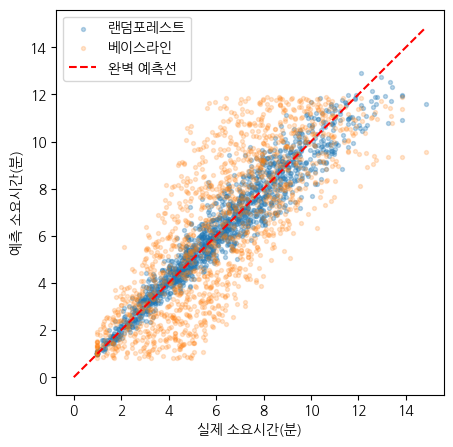

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, rf_pred, s=8, alpha=0.3, label="랜덤포레스트")
plt.scatter(y_test, baseline_pred, s=8, alpha=0.2, label="베이스라인")
plt.plot([0, y_test.max()], [0, y_test.max()], "r--", label="완벽 예측선")
plt.xlabel("실제 소요시간(분)"); plt.ylabel("예측 소요시간(분)")
plt.legend(); plt.show()

어떤 특징이 중요했는지 (크기 vs 중량 등)

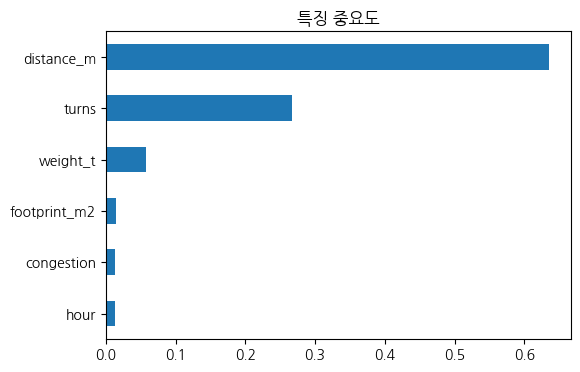

In [ ]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values()
importance.plot(kind="barh", figsize=(6,4))
plt.title("특징 중요도")
plt.show()

예측

In [ ]:
def predict_eta(distance_m, weight_t, length_m, width_m, turns, hour, congestion):
    footprint = length_m * width_m
    x = pd.DataFrame([{
        "distance_m": distance_m,
        "weight_t": weight_t,
        "footprint_m2": footprint,
        "turns": turns,
        "hour": hour,
        "congestion": congestion,
    }])
    pred_rf = rf.predict(x)[0]
    pred_lin = lin.predict(x)[0]
    pred_base = distance_m / c
    print(f"거리 {distance_m}m · 중량 {weight_t}t · 크기 {length_m}x{width_m}m · 회전 {turns}회 · {hour}시 · 혼잡도 {congestion}")
    print(f"  베이스라인(거리만):     {pred_base:.1f} 분")
    print(f"  선형회귀:              {pred_lin:.1f} 분")
    print(f"  랜덤포레스트:          {pred_rf:.1f} 분")

# 예시 값 — 자유롭게 바꿔서 실행
predict_eta(distance_m=500, weight_t=300, length_m=20, width_m=12, turns=3, hour=9, congestion=4)

거리 500m · 중량 300t · 크기 20x12m · 회전 3회 · 9시 · 혼잡도 4
  베이스라인(거리만):     5.0 분
  선형회귀:              6.0 분
  랜덤포레스트:          5.7 분


예측 슬라이더

In [ ]:
!pip -q install ipywidgets
from ipywidgets import interact, IntSlider, FloatSlider

@interact(
    distance_m=IntSlider(min=80, max=1200, step=10, value=500, description="거리(m)"),
    weight_t=IntSlider(min=30, max=600, step=10, value=300, description="중량(t)"),
    length_m=FloatSlider(min=3, max=40, step=1, value=20, description="길이(m)"),
    width_m=FloatSlider(min=3, max=25, step=1, value=12, description="폭(m)"),
    turns=IntSlider(min=0, max=5, step=1, value=3, description="회전수"),
    hour=IntSlider(min=6, max=18, step=1, value=9, description="시각"),
    congestion=IntSlider(min=0, max=10, step=1, value=4, description="혼잡도"),
)
def demo(distance_m, weight_t, length_m, width_m, turns, hour, congestion):
    predict_eta(distance_m, weight_t, length_m, width_m, turns, hour, congestion)

interactive(children=(IntSlider(value=500, description='거리(m)', max=1200, min=80, step=10), IntSlider(value=30…

In [24]:
from IPython.display import HTML

with open('/content/drive/MyDrive/K조선 해커톤/yard-logistics-prototype-2.html', 'r', encoding='utf-8') as f:
    html_content = f.read()

HTML(html_content)